# Práctica C1-W3: De la regresión logística a una red neuronal


## Propósito

Construir desde cero, con NumPy, un clasificador binario y reconocer que:

1. Una neurona sigmoide equivale a un modelo de regresión logística.
2. Una capa oculta con activación NO lineal permite aprender fronteras no lineales.
3. El entrenamiento consiste en propagación hacia adelante, cálculo del costo, retropropagación y actualización de parámetros.

> Esta práctica incluye estos conceptos teóricos fundamentales. No utiliza regularización ni redes profundas.

## Resultados de aprendizaje

Al terminar podrás:

- identificar las dimensiones de $X$, $Y$, $W$ y $b$;
- implementar `sigmoid` y `tanh` de manera vectorizada;
- programar propagación hacia adelante y entropía cruzada binaria;
- derivar e implementar los gradientes de una red con una capa oculta;
- comparar una neurona sigmoide con una red neuronal pequeña.

## Convención de dimensiones

Cada **columna** representa un ejemplo:

$$X\in\mathbb{R}^{n_x\times m},\qquad Y\in\mathbb{R}^{1\times m}.$$

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

## 1. Datos: un problema que no es linealmente separable

Usaremos dos medias lunas. Una recta no puede separar perfectamente las clases; por eso es un buen ejemplo para comparar regresión logística y una red neuronal.

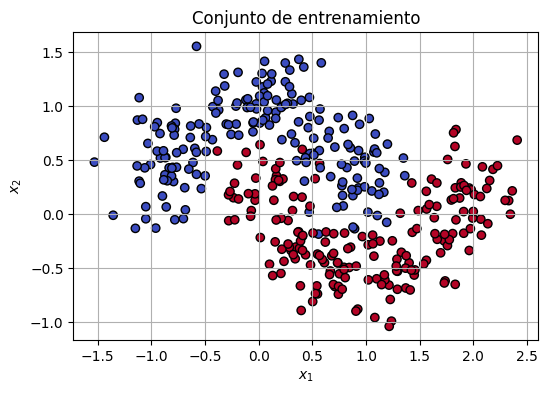

X_train: (2, 375)
Y_train: (1, 375)
X_test:  (2, 125)
Y_test:  (1, 125)


In [7]:
X_raw, y_raw = make_moons(n_samples=500, noise=0.22, random_state=SEED)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.25, random_state=SEED, stratify=y_raw
)

# Convención de Andrew Ng: cada ejemplo es una columna
X_train, X_test = X_train_raw.T, X_test_raw.T
Y_train, Y_test = y_train_raw.reshape(1, -1), y_test_raw.reshape(1, -1)

plt.scatter(X_train[0], X_train[1], c=Y_train.ravel(), cmap="coolwarm", edgecolor="k")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Conjunto de entrenamiento")
plt.show()

print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)
print("X_test: ", X_test.shape)
print("Y_test: ", Y_test.shape)

### Ejercicio 1. Dimensiones

Sin ejecutar código adicional, responde:

1. ¿Cuánto valen $n_x$, $m_{train}$ y $m_{test}$?
2. Si la capa oculta tiene cuatro neuronas, ¿qué dimensiones deben tener $W^{[1]}$, $b^{[1]}$, $W^{[2]}$ y $b^{[2]}$?

In [8]:
# RESPUESTA
# n_x = 2, m_train = 375, m_test = 125
# W1: (4, 2), b1: (4, 1), W2: (1, 4), b2: (1, 1)

## 2. Función sigmoide y entropía cruzada

La salida de una neurona es transformada por la función sigmoide:

$$Z=W^TX+b,\qquad A=\sigma(Z)=\frac{1}{1+e^{-Z}}.$$

Función de costo para clasificación binaria usando la pérdida de entropía cruzada:

$$J=-\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log a^{(i)}+(1-y^{(i)})\log(1-a^{(i)})\right].$$


In [9]:
def sigmoid(z):
    """Calcula la sigmoide elemento a elemento."""
    return 1.0 / (1.0 + np.exp(-z))

z_test = np.array([-2.0, 0.0, 2.0])
print(sigmoid(z_test))


[0.11920292 0.5        0.88079708]


In [10]:
def binary_cross_entropy(A, Y):
    """Entropía cruzada binaria promedio."""
    eps = 1e-12 #número muy pequeño para evitar log(0), que no está definido y NumPy produciría -inf
    A = np.clip(A, eps, 1.0 - eps) #np.clip obliga a que todos los valores de A estén dentro del intervalo:[eps,1−eps] [0.000000000001, 0.999999999999]
    m = Y.shape[1] #número de columnas
    return float(-np.sum(Y * np.log(A) + (1 - Y) * np.log(1 - A)) / m)

A_test = np.array([[0.9, 0.2, 0.7]])
Y_demo = np.array([[1, 0, 1]])
print("probando... Costo:", binary_cross_entropy(A_test, Y_demo))
assert np.isclose(binary_cross_entropy(A_test, Y_demo), 0.2283930036)

probando... Costo: 0.22839300363692283


## 3. Modelo base: una neurona sigmoide

Este modelo es regresión logística escrita con la notación de redes neuronales. Para $m$ ejemplos:

$$dZ=A-Y,\qquad dW=\frac{1}{m}XdZ^T,\qquad db=\frac{1}{m}\sum dZ.$$

In [11]:
def train_logistic(X, Y, learning_rate=0.8, iterations=3000):
    n_x, m = X.shape
    W = np.zeros((n_x, 1))# tenemos una sola neurona, entonces los pesos sí pueden inicializarse en cero.
    b = 0.0
    history = []

    for i in range(iterations):
        Z = W.T @ X + b
        A = sigmoid(Z)
        cost = binary_cross_entropy(A, Y)

        dZ = A - Y
        dW = (X @ dZ.T) / m
        db = float(np.sum(dZ) / m)

        W -= learning_rate * dW
        b -= learning_rate * db
        if i % 100 == 0:
            history.append(cost)
    return {"W": W, "b": b}, history   #devuelve diccionario {"W": W, "b": b} y los costos históricos

log_params, log_history = train_logistic(X_train, Y_train)
print("Costo inicial/final:", log_history[0], log_history[-1])

Costo inicial/final: 0.6931471805599454 0.2830912823308886


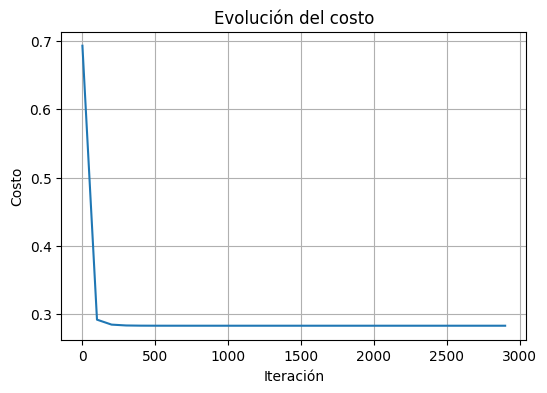

In [12]:
plt.plot(np.arange(len(log_history)) * 100, log_history)
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Evolución del costo")
plt.show()


## Predicción y clasificación con un umbral de 0.5

Una vez entrenado el modelo, se calculan las probabilidades de que cada ejemplo pertenezca a la clase positiva:

$$
P(Y=1\mid X)=A=\sigma(W^TX+b)
$$

La función sigmoide genera valores entre 0 y 1. Estos valores se interpretan como probabilidades, pero todavía deben convertirse en las clases `0` o `1`.

Para hacerlo, se utiliza un **umbral de decisión de 0.5**:

$$
\hat{Y}=
\begin{cases}
1, & \text{si } P(Y=1\mid X)\geq 0.5,\\
0, & \text{si } P(Y=1\mid X)<0.5.
\end{cases}
$$

La expresión:

```python
probabilities >= 0.5

In [13]:
def predict_logistic(params, X):
    probabilities = sigmoid(params["W"].T @ X + params["b"])  #WT*X+b
    return (probabilities >= 0.5).astype(int)  #clasifica utilizando un umbral de 0.5; #astype: convierte los valores booleanos en enteros

#Devuelve el porcentaje de predicciones en las que Y_hat coincide con Y.
def accuracy(Y_hat, Y):
    return 100.0 * np.mean(Y_hat == Y)

print(f"Exactitud train: {accuracy(predict_logistic(log_params, X_train), Y_train):.2f}%")
print(f"Exactitud test:  {accuracy(predict_logistic(log_params, X_test), Y_test):.2f}%")

Exactitud train: 86.13%
Exactitud test:  83.20%


### Pregunta de análisis

Aunque el costo disminuye, el modelo sigue cometiendo errores sistemáticos. ¿La causa principal es que faltan iteraciones o que la frontera $W^TX+b=0$ sólo puede ser lineal? Justifica brevemente.

In [14]:
# RESPUESTA: la limitación principal es la forma lineal de la frontera de decisión.
# Más iteraciones pueden optimizar mejor el mismo modelo, pero no cambian su capacidad representacional.

## Gráfica de las predicciones y la frontera de decisión

La única neurona del modelo calcula:

$$
Z=w_1x_1+w_2x_2+b
$$

y posteriormente aplica la función sigmoide:

$$
A=\sigma(Z).
$$

La predicción se convierte en la clase $1$ cuando $A\geq 0.5$. Como:

$$
\sigma(0)=0.5,
$$

la frontera de decisión se encuentra en los puntos que cumplen:

$$
w_1x_1+w_2x_2+b=0.
$$

Despejando $x_2$:

$$
x_2=-\frac{w_1x_1+b}{w_2}.
$$

Por tanto, la frontera de decisión de este modelo es una recta. El fondo de la gráfica muestra la clase predicha por la neurona, mientras que la línea negra representa los puntos donde la probabilidad es exactamente $0.5$.

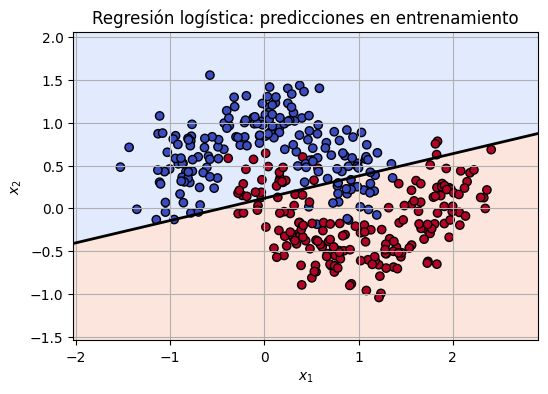

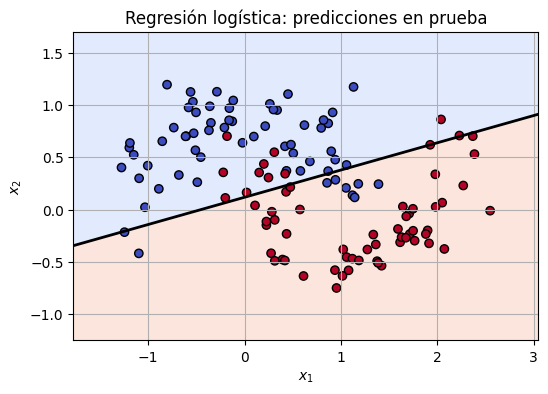

In [15]:
def plot_logistic_predictions(params, X, Y, title):
    """Grafica las clases predichas y la frontera de decisión."""

    # Límites de la gráfica
    x1_min, x1_max = X[0].min() - 0.5, X[0].max() + 0.5
    x2_min, x2_max = X[1].min() - 0.5, X[1].max() + 0.5

    # Malla de puntos que cubre el plano
    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 300),
        np.linspace(x2_min, x2_max, 300)
    )

    # Cada punto de la malla se coloca como una columna
    X_grid = np.vstack((xx1.ravel(), xx2.ravel()))

    # Probabilidad y clase predicha para cada punto
    probabilities = sigmoid(
        params["W"].T @ X_grid + params["b"]
    )
    predictions = (probabilities >= 0.5).astype(int)

    # Recuperar la forma de la malla
    probability_grid = probabilities.reshape(xx1.shape)
    prediction_grid = predictions.reshape(xx1.shape)

    # Regiones clasificadas como 0 y 1
    plt.contourf(
        xx1,
        xx2,
        prediction_grid,
        levels=[-0.5, 0.5, 1.5],
        cmap="coolwarm",
        alpha=0.25
    )

    # Frontera donde P(Y=1|X) = 0.5
    plt.contour(
        xx1,
        xx2,
        probability_grid,
        levels=[0.5],
        colors="black",
        linewidths=2
    )

    # Datos reales
    plt.scatter(
        X[0],
        X[1],
        c=Y.ravel(),
        cmap="coolwarm",
        edgecolor="k"
    )

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.show()


plot_logistic_predictions(
    log_params,
    X_train,
    Y_train,
    "Regresión logística: predicciones en entrenamiento"
)

plot_logistic_predictions(
    log_params,
    X_test,
    Y_test,
    "Regresión logística: predicciones en prueba"
)

## 4. Red neuronal con una capa oculta

Arquitectura:

$$Z^{[1]}=W^{[1]}X+b^{[1]},\quad A^{[1]}=\tanh(Z^{[1]}),$$
$$Z^{[2]}=W^{[2]}A^{[1]}+b^{[2]},\quad A^{[2]}=\sigma(Z^{[2]}).$$

Usaremos `tanh` en la capa oculta y `sigmoid` en la salida binaria.

In [16]:
def initialize_parameters(n_x, n_h, n_y=1, seed=SEED):
    rng = np.random.default_rng(seed)
    W1 = rng.standard_normal((n_h, n_x)) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = rng.standard_normal((n_y, n_h)) * 0.01
    b2 = np.zeros((n_y, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}

#llamar función
params_test = initialize_parameters(n_x=2, n_h=4)#defino 2 inputs y 4 neuronas
for name, value in params_test.items():
    print(name, value.shape)

W1 (4, 2)
b1 (4, 1)
W2 (1, 4)
b2 (1, 1)


### ¿Por qué no inicializamos todos los pesos en cero?

Si las neuronas ocultas comienzan con los mismos pesos, reciben los mismos gradientes y permanecen idénticas. La inicialización aleatoria **rompe la simetría** para que aprendan características diferentes. Los sesgos sí pueden comenzar en cero.

In [17]:
def forward_propagation(X, params):
    W1, b1 = params["W1"], params["b1"]
    W2, b2 = params["W2"], params["b2"]

    Z1 = W1 @ X + b1
    A1 = np.tanh(Z1)
    Z2 = W2 @ A1 + b2
    A2 = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache
#Se utilizan sólo los primeros cinco ejemplos para hacer una prueba rápida de forward_propagation y verificar que las dimensiones sean correctas
A2_test, cache_test = forward_propagation(X_train[:, :5], params_test) #
print("A2 shape:", A2_test.shape)
assert A2_test.shape == (1, 5)

A2 shape: (1, 5)


## 5. Retropropagación

Para la capa de salida se combinan una activación sigmoide y la entropía cruzada binaria. Al aplicar la regla de la cadena, sus derivadas se simplifican a:

$$dZ^{[2]}=A^{[2]}-Y.$$

En la capa oculta se usa `tanh`. Como $A^{[1]}=\tanh(Z^{[1]})$:

$$\frac{d}{dZ^{[1]}}\tanh(Z^{[1]})=1-\tanh^2(Z^{[1]})=1-(A^{[1]})^2.$$

Por tanto:

$$dZ^{[1]}=\left(W^{[2]T}dZ^{[2]}\right)\odot\left(1-(A^{[1]})^2\right).$$

El símbolo $\odot$ representa la multiplicación elemento a elemento. Los gradientes de los parámetros son:

$$dW^{[2]}=\frac{1}{m}dZ^{[2]}A^{[1]T},\qquad
db^{[2]}=\frac{1}{m}\sum_{i=1}^{m}dZ^{[2](i)},$$

$$dW^{[1]}=\frac{1}{m}dZ^{[1]}X^T,\qquad
db^{[1]}=\frac{1}{m}\sum_{i=1}^{m}dZ^{[1](i)}.$$

La suma de cada $db$ se realiza sobre los $m$ ejemplos; por eso se usa `axis=1` y `keepdims=True`.


In [18]:
def backward_propagation(X, Y, params, cache):
    m = X.shape[1]
    W2 = params["W2"]
    A1, A2 = cache["A1"], cache["A2"]

    dZ2 = A2 - Y
    dW2 = (dZ2 @ A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m  #axis=1 suma los valores horizontalmente, es decir, a través de todos los ejemplos m.
                              #keepdims=True conserva el resultado como una matriz de 1 columna; un gradiente db por neurona
    dZ1 = (W2.T @ dZ2) * (1 - A1**2)
    dW1 = (dZ1 @ X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

_, cache_test = forward_propagation(X_train[:, :5], params_test)
grads_test = backward_propagation(X_train[:, :5], Y_train[:, :5], params_test, cache_test)
for name, value in grads_test.items():
    print(name, value.shape)

dW1 (4, 2)
db1 (4, 1)
dW2 (1, 4)
db2 (1, 1)


In [19]:
def update_parameters(params, grads, learning_rate):
    for layer in (1, 2):
        params[f"W{layer}"] -= learning_rate * grads[f"dW{layer}"]
        params[f"b{layer}"] -= learning_rate * grads[f"db{layer}"]
    return params

## 6. Integración del algoritmo de entrenamiento

Observa el ciclo completo: `forward -> costo -> backward -> actualización`.

La tasa de aprendizaje $lpha$ es un hiperparámetro que controla el tamaño de cada actualización:

$$W^{[l]} \leftarrow W^{[l]}-lpha\,dW^{[l]},\qquad
b^{[l]} \leftarrow b^{[l]}-lpha\,db^{[l]}.$$

No existe una regla matemática universal que obligue a $lpha\leq 1$: su escala depende del problema y de los gradientes. Sin embargo, un valor demasiado grande puede hacer que el costo oscile o diverja. En esta práctica usaremos $lpha=0.8$, que produce un entrenamiento estable con estos datos.


In [20]:
def train_neural_network(X, Y, n_h=4, learning_rate=0.8, iterations=3000, seed=SEED):
    params = initialize_parameters(X.shape[0], n_h, seed=seed)
    history = []

    for i in range(iterations):
        A2, cache = forward_propagation(X, params)
        cost = binary_cross_entropy(A2, Y)
        grads = backward_propagation(X, Y, params, cache)
        params = update_parameters(params, grads, learning_rate)
        if i % 100 == 0:
            history.append(cost)
    return params, history

nn_params, nn_history = train_neural_network(X_train, Y_train)
print("Costo inicial/final:", nn_history[0], nn_history[-1])


Costo inicial/final: 0.6931582646302168 0.0921080725148846


Exactitud train: 98.13%
Exactitud test:  96.00%


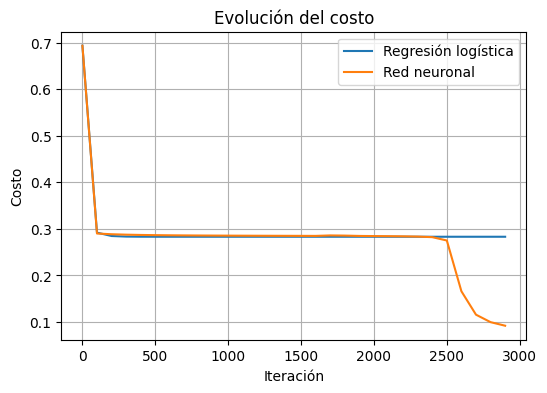

In [21]:
def predict_nn(params, X):
    A2, _ = forward_propagation(X, params)
    return (A2 >= 0.5).astype(int)

print(f"Exactitud train: {accuracy(predict_nn(nn_params, X_train), Y_train):.2f}%")
print(f"Exactitud test:  {accuracy(predict_nn(nn_params, X_test), Y_test):.2f}%")

plt.plot(np.arange(len(log_history)) * 100, log_history, label="Regresión logística")
plt.plot(np.arange(len(nn_history)) * 100, nn_history, label="Red neuronal")
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Evolución del costo")
plt.legend()
plt.show()

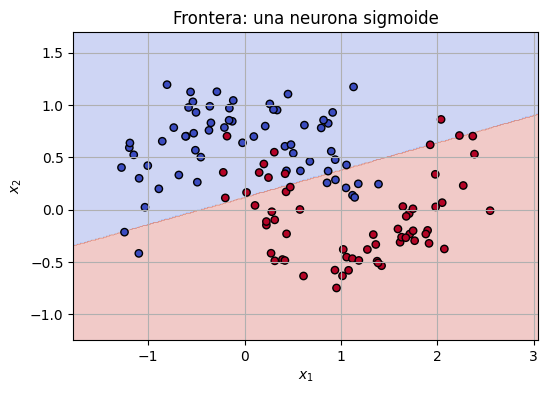

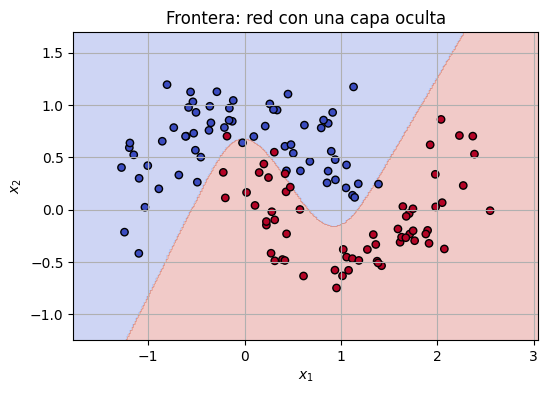

In [22]:
def plot_decision_boundary(predict_fn, X, Y, title):
    x_min, x_max = X[0].min() - 0.5, X[0].max() + 0.5
    y_min, y_max = X[1].min() - 0.5, X[1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()].T
    zz = predict_fn(grid).reshape(xx.shape)
    plt.contourf(xx, yy, zz, alpha=0.28, cmap="coolwarm")
    plt.scatter(X[0], X[1], c=Y.ravel(), cmap="coolwarm", edgecolor="k", s=28)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.show()

plot_decision_boundary(lambda x: predict_logistic(log_params, x), X_test, Y_test,
                       "Frontera: una neurona sigmoide")
plot_decision_boundary(lambda x: predict_nn(nn_params, x), X_test, Y_test,
                       "Frontera: red con una capa oculta")

## 7. Experimento: número de neuronas ocultas

Entrena modelos con $n_h\in\{1,2,4,8,16\}$. Registra la exactitud de entrenamiento y prueba. No concluyas que “más neuronas siempre es mejor”: compara la capacidad del modelo y la generalización.

In [23]:
results = []
for n_h in [1, 2, 4, 8, 16]:
    p, _ = train_neural_network(X_train, Y_train, n_h=n_h, iterations=5000)
    train_acc = accuracy(predict_nn(p, X_train), Y_train)
    test_acc = accuracy(predict_nn(p, X_test), Y_test)
    results.append((n_h, train_acc, test_acc))

print("n_h | train (%) | test (%)")
for n_h, train_acc, test_acc in results:
    print(f"{n_h:>3} | {train_acc:>9.2f} | {test_acc:>8.2f}")


n_h | train (%) | test (%)
  1 |     85.07 |    84.80
  2 |     85.33 |    83.20
  4 |     97.87 |    96.00
  8 |     97.87 |    96.00
 16 |     86.13 |    83.20


## 8. Preguntas

1. ¿Qué parte de la regresión logística reaparece sin cambios en la capa de salida?<br> R:
Es la función de activación sigmoide y la función de costo de entropía cruzada binaria
---

2. ¿Por qué una activación lineal en la capa oculta no aumentaría la capacidad representacional?<br>R:
Si todas las capas ocultas tuvieran una activación lineal, la composición de múltiples transformaciones lineales (multiplicaciones de matrices) seguiría siendo una única transformación lineal. Esto significa que la red neuronal, sin importar cuántas capas tenga, solo podría aprender relaciones lineales, lo que limitaría su capacidad para modelar fronteras de decisión complejas y no lineales.

---
3. ¿Qué evidencia muestra que la red aprendió una frontera no lineal?<br>
R: La evidencia clave se observa en la gráfica de la frontera de decisión para la red neuronal
---
4. Explica con tus palabras las cuatro etapas de una iteración de entrenamiento. <br>
R: ```
  - Propagación hacia adelante (Forward Propagation): Se calcula la salida (predicción) de la red (A) a partir de las entradas (X) y los parámetros actuales (W, b) de cada capa.
  - Cálculo del costo: Se compara la predicción de la red (A) con los valores reales (Y) utilizando una función de costo (en este caso, entropía cruzada binaria) para cuantificar qué tan bien se desempeña el modelo.
  - Retropropagación (Backward Propagation): Se calcula el gradiente del costo con respecto a cada parámetro (dW, db). Esto implica propagar el error hacia atrás a través de las capas de la red.
  - Actualización de parámetros: Utilizando los gradientes calculados y una tasa de aprendizaje (alpha), se ajustan los parámetros (W, b) de la red para minimizar el costo en la siguiente iteración. Este es el paso de 'aprendizaje'.


## Puente hacia redes neuronales con mas de una capa oculta

En esta notebook programamos una arquitectura fija de una capa oculta y una capa de salida. En la siguiente práctica se generalizará esta idea a una red profunda de $L$ capas mediante:

- notación general $W^{[l]}, b^{[l]}, Z^{[l]}, A^{[l]}$;
- funciones reutilizables para propagación hacia adelante y hacia atrás;
- verificación sistemática de las dimensiones de cada matriz;
- diferenciación entre parámetros e hiperparámetros.


# Parte 2. Práctica C1-W4: Red neuronal profunda de $L$ capas

## Propósito

Generalizar la red anterior a una arquitectura con varias capas ocultas. Al finalizar podrás:

1. representar una arquitectura mediante `layer_dims`;
2. inicializar los parámetros de todas las capas;
3. construir una propagación hacia adelante modular;
4. aplicar retropropagación desde la capa $L$ hasta la capa 1;
5. entrenar y evaluar una red neuronal profunda.

Usaremos un conjunto de **dos espirales entrelazadas**. Su frontera es más compleja que la de `make_moons` y constituye un escenario apropiado para experimentar con varias capas ocultas.

## 9. Conjunto de datos: dos espirales

Cada ejemplo sigue siendo una columna:

$$X\in\mathbb{R}^{2\times m},\qquad Y\in\mathbb{R}^{1\times m}.$$

La función siguiente genera dos clases que se enrollan una alrededor de la otra. Después dividimos los datos y los estandarizamos utilizando solamente la media y la desviación estándar del conjunto de entrenamiento.

X_sp_train: (2, 600)
Y_sp_train: (1, 600)
X_sp_test:  (2, 200)
Y_sp_test:  (1, 200)


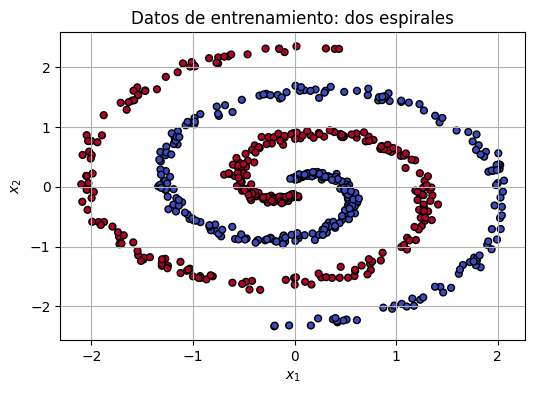

In [24]:
def make_spiral_dataset(points_per_class=400, noise=0.20, seed=SEED):
    rng = np.random.default_rng(seed)
    X = np.zeros((2 * points_per_class, 2))
    y = np.zeros(2 * points_per_class, dtype=int)

    for class_id in (0, 1):
        indices = slice(class_id * points_per_class, (class_id + 1) * points_per_class)
        radius = np.linspace(0.05, 1.0, points_per_class)
        theta = np.linspace(class_id * np.pi, (class_id + 3.0) * np.pi, points_per_class)
        theta += rng.normal(0.0, noise, points_per_class)
        X[indices] = np.c_[radius * np.sin(theta), radius * np.cos(theta)]
        y[indices] = class_id
    return X, y

X_spiral_raw, y_spiral_raw = make_spiral_dataset()
X_sp_train_raw, X_sp_test_raw, y_sp_train_raw, y_sp_test_raw = train_test_split(
    X_spiral_raw, y_spiral_raw, test_size=0.25, random_state=SEED,
    stratify=y_spiral_raw
)

mean_sp = X_sp_train_raw.mean(axis=0, keepdims=True)
std_sp = X_sp_train_raw.std(axis=0, keepdims=True)
X_sp_train = ((X_sp_train_raw - mean_sp) / std_sp).T
X_sp_test = ((X_sp_test_raw - mean_sp) / std_sp).T
Y_sp_train = y_sp_train_raw.reshape(1, -1)
Y_sp_test = y_sp_test_raw.reshape(1, -1)

print("X_sp_train:", X_sp_train.shape)
print("Y_sp_train:", Y_sp_train.shape)
print("X_sp_test: ", X_sp_test.shape)
print("Y_sp_test: ", Y_sp_test.shape)

plt.scatter(X_sp_train[0], X_sp_train[1], c=Y_sp_train.ravel(),
            cmap="coolwarm", edgecolor="k", s=24)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Datos de entrenamiento: dos espirales")
plt.show()

### Ejercicio 2. Arquitectura y dimensiones

Usaremos inicialmente:

```python
layer_dims = [2, 16, 8, 4, 1]
```

Esto representa $n^{[0]}=2$ entradas, tres capas ocultas de 16, 8 y 4 neuronas, y una neurona de salida.

1. ¿Cuántas capas con parámetros tiene la red?
2. Escribe las dimensiones de cada $W^{[l]}$ y $b^{[l]}$.
3. `len(layer_dims) - 1` proporciona el número de capas con parámetros.

In [25]:
# RESPUESTA
# L = 4 capas con parámetros: tres ocultas y una de salida.
# W1: (16, 2), b1: (16, 1)
# W2: (8, 16), b2: (8, 1)
# W3: (4, 8),  b3: (4, 1)
# W4: (1, 4),  b4: (1, 1)
# layer_dims también incluye la capa de entrada, que no tiene parámetros.

## 10. Inicialización de una red profunda

Para una capa con activación ReLU utilizaremos inicialización de He et al. (2015):

$$W^{[l]}\sim\mathcal{N}(0,1)\sqrt{\frac{2}{n^{[l-1]}}},\qquad b^{[l]}=0.$$

El factor de escala ayuda a evitar que las activaciones y los gradientes crezcan o disminuyan excesivamente al atravesar varias capas.

En una red neuronal profunda, los pesos no deben inicializarse todos en cero, porque las neuronas aprenderían exactamente lo mismo. Por ello, se utilizan valores aleatorios.

La **inicialización de He** genera pesos aleatorios y ajusta su magnitud de acuerdo con el número de entradas de cada capa:

$$
W^{[l]}=\text{valores aleatorios}\times
\sqrt{\frac{2}{n^{[l-1]}}},
$$

donde:

- $W^{[l]}$ contiene los pesos de la capa $l$;
- $n^{[l-1]}$ es el número de neuronas de la capa anterior o número de entradas de la capa actual;
- el factor $\sqrt{2/n^{[l-1]}}$ controla la magnitud inicial de los pesos.

He se recomienda especialmente cuando las capas ocultas utilizan ReLU, porque ReLU convierte aproximadamente la mitad de sus entradas en cero.

La inicialización de He genera pesos aleatorios y los escala según el número de entradas de la capa para mantener estable la información durante la propagación hacia adelante y hacia atrás.

En NumPy se implementa de la siguiente manera:

```python
W = np.random.randn(n_l, n_anterior) * np.sqrt(2.0 / n_anterior)
b = np.zeros((n_l, 1))

In [33]:
def initialize_parameters_deep(layer_dims, seed=SEED):
    rng = np.random.default_rng(seed)
    params = {}
    L = len(layer_dims) - 1

    for l in range(1, L + 1):
        params[f"W{l}"] = (
            rng.standard_normal((layer_dims[l], layer_dims[l - 1]))
            * np.sqrt(2.0 / layer_dims[l - 1])
        )
        params[f"b{l}"] = np.zeros((layer_dims[l], 1))
        assert params[f"W{l}"].shape == (layer_dims[l], layer_dims[l - 1])
        assert params[f"b{l}"].shape == (layer_dims[l], 1)
    return params

deep_params_test = initialize_parameters_deep([2, 16, 8, 4, 1])
for name, value in deep_params_test.items():
    print(name, value.shape)

W1 (16, 2)
b1 (16, 1)
W2 (8, 16)
b2 (8, 1)
W3 (4, 8)
b3 (4, 1)
W4 (1, 4)
b4 (1, 1)


## 11. Propagación hacia adelante modular

En cualquier capa se realiza primero el paso lineal:

$$Z^{[l]}=W^{[l]}A^{[l-1]}+b^{[l]}.$$

Para las capas ocultas usaremos ReLU:

$$A^{[l]}=\operatorname{ReLU}(Z^{[l]})=\max(0,Z^{[l]}),$$

y para la última capa, sigmoide:

$$A^{[L]}=\sigma(Z^{[L]}).$$

Cada capa guarda una caché con los valores necesarios para la retropropagación.
La caché funciona como la “memoria” de cada capa: guarda durante el forward-propagation los valores que esa misma capa necesitará posteriormente durante el back-propagation

In [34]:
def relu(Z):
    return np.maximum(0.0, Z)

def linear_forward(A_prev, W, b):
    Z = W @ A_prev + b
    assert Z.shape == (W.shape[0], A_prev.shape[1])
    return Z, (A_prev, W, b)

def linear_activation_forward(A_prev, W, b, activation):
    Z, linear_cache = linear_forward(A_prev, W, b)
    if activation == "relu":
        A = relu(Z)
    elif activation == "sigmoid":
        A = sigmoid(Z)
    else:
        raise ValueError("Activación no reconocida")
    return A, (linear_cache, Z) #regresa A y caché (linear_cache, Z), que se utilizará después en la retropropagación.

def L_model_forward(X, params):
    caches = []
    A = X
    L = len(params) // 2

    for l in range(1, L):
        A, cache = linear_activation_forward(
            A, params[f"W{l}"], params[f"b{l}"], activation="relu"
        )
        caches.append(cache)

    AL, cache = linear_activation_forward(
        A, params[f"W{L}"], params[f"b{L}"], activation="sigmoid"
    )
    caches.append(cache) #se guarda una caché por cada capa
    assert AL.shape == (1, X.shape[1])
    return AL, caches

AL_test, caches_test = L_model_forward(X_sp_train[:, :5], deep_params_test)
print("AL shape:", AL_test.shape)
print("Número de cachés:", len(caches_test))

AL shape: (1, 5)
Número de cachés: 4


## 12. Retropropagación para $L$ capas

En la capa de salida, sigmoide más entropía cruzada permite utilizar directamente:

$$dZ^{[L]}=A^{[L]}-Y.$$

En una capa oculta con ReLU:

$$dZ^{[l]}=dA^{[l]}\odot\mathbb{1}(Z^{[l]}>0).$$

Una vez conocido $dZ^{[l]}$, el paso lineal hacia atrás es:

$$dW^{[l]}=\frac{1}{m}dZ^{[l]}A^{[l-1]T},$$

$$db^{[l]}=\frac{1}{m}\sum_{i=1}^{m}dZ^{[l](i)},$$

$$dA^{[l-1]}=W^{[l]T}dZ^{[l]}.$$

La retropropagación recorre las capas en orden inverso: $L,L-1,\ldots,1$.

In [28]:
def linear_backward(dZ, linear_cache):
    A_prev, W, _ = linear_cache
    m = A_prev.shape[1]
    dW = (dZ @ A_prev.T) / m
    db = np.sum(dZ, axis=1, keepdims=True) / m
    dA_prev = W.T @ dZ
    assert dW.shape == W.shape
    assert db.shape == (W.shape[0], 1)
    assert dA_prev.shape == A_prev.shape
    return dA_prev, dW, db

def linear_activation_backward(dA, cache, activation):
    linear_cache, Z = cache
    if activation == "relu":
        dZ = dA * (Z > 0)
    elif activation == "sigmoid":
        A = sigmoid(Z)
        dZ = dA * A * (1.0 - A)
    else:
        raise ValueError("Activación no reconocida")
    return linear_backward(dZ, linear_cache)

def L_model_backward(AL, Y, caches):
    grads = {}
    L = len(caches)

    # Capa L: sigmoide + entropía cruzada
    linear_cache_L, _ = caches[-1]
    dZL = AL - Y
    dA_prev, grads[f"dW{L}"], grads[f"db{L}"] = linear_backward(
        dZL, linear_cache_L
    )

    # Capas ocultas L-1, ..., 1
    for l in reversed(range(1, L)):
        dA_prev, grads[f"dW{l}"], grads[f"db{l}"] = linear_activation_backward(
            dA_prev, caches[l - 1], activation="relu"
        )
    return grads

grads_deep_test = L_model_backward(
    AL_test, Y_sp_train[:, :5], caches_test
)
for name in sorted(grads_deep_test):
    print(name, grads_deep_test[name].shape)

dW1 (16, 2)
dW2 (8, 16)
dW3 (4, 8)
dW4 (1, 4)
db1 (16, 1)
db2 (8, 1)
db3 (4, 1)
db4 (1, 1)


## 13. Actualización y entrenamiento

Para todas las capas aplicamos descenso del gradiente:

$$W^{[l]}\leftarrow W^{[l]}-\alpha dW^{[l]},\qquad
b^{[l]}\leftarrow b^{[l]}-\alpha db^{[l]}.$$

La lista `layer_dims` permite cambiar la profundidad y el número de neuronas sin reescribir las funciones de propagación.

In [29]:
def update_parameters_deep(params, grads, learning_rate):
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f"W{l}"] -= learning_rate * grads[f"dW{l}"]
        params[f"b{l}"] -= learning_rate * grads[f"db{l}"]
    return params

def train_deep_network(X, Y, layer_dims, learning_rate=0.03,
                       iterations=8000, seed=SEED, print_cost=True):
    params = initialize_parameters_deep(layer_dims, seed=seed)
    history = []
    history_iterations = []

    for i in range(iterations):
        AL, caches = L_model_forward(X, params)
        cost = binary_cross_entropy(AL, Y)
        grads = L_model_backward(AL, Y, caches)
        params = update_parameters_deep(params, grads, learning_rate)

        if i % 200 == 0 or i == iterations - 1:
            history.append(cost)
            history_iterations.append(i)
            if print_cost and i % 1000 == 0:
                print(f"Iteración {i:5d} | costo: {cost:.6f}")

    return params, history, history_iterations

deep_layer_dims = [2, 16, 8, 4, 1]
deep_params, deep_history, deep_history_iterations = train_deep_network(
    X_sp_train, Y_sp_train, deep_layer_dims,
    learning_rate=0.03, iterations=8000, print_cost=True
)

Iteración     0 | costo: 0.751671
Iteración  1000 | costo: 0.624641
Iteración  2000 | costo: 0.509261
Iteración  3000 | costo: 0.245717
Iteración  4000 | costo: 0.066545
Iteración  5000 | costo: 0.029187
Iteración  6000 | costo: 0.018260
Iteración  7000 | costo: 0.013197


Exactitud train: 100.00%
Exactitud test:  100.00%


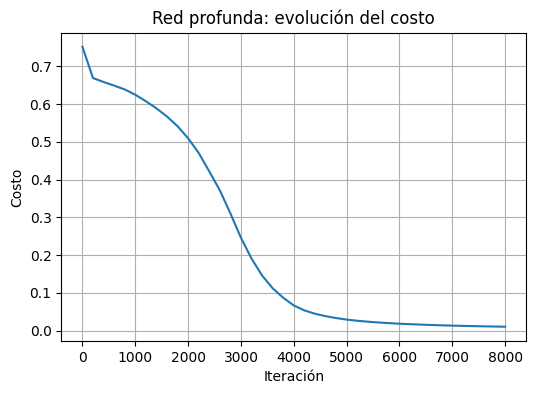

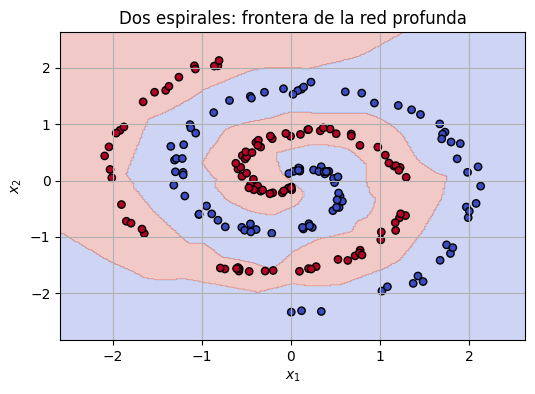

In [30]:
def predict_deep(params, X):
    probabilities, _ = L_model_forward(X, params)
    return (probabilities >= 0.5).astype(int)

deep_train_acc = accuracy(predict_deep(deep_params, X_sp_train), Y_sp_train)
deep_test_acc = accuracy(predict_deep(deep_params, X_sp_test), Y_sp_test)
print(f"Exactitud train: {deep_train_acc:.2f}%")
print(f"Exactitud test:  {deep_test_acc:.2f}%")

plt.plot(deep_history_iterations, deep_history)
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Red profunda: evolución del costo")
plt.show()

plot_decision_boundary(
    lambda x: predict_deep(deep_params, x),
    X_sp_test, Y_sp_test,
    "Dos espirales: frontera de la red profunda"
)

## 14. Experimento: profundidad y arquitectura

Compara las siguientes arquitecturas sobre el mismo conjunto de datos:

- `[2, 8, 1]`: una capa oculta;
- `[2, 16, 8, 1]`: dos capas ocultas;
- `[2, 16, 8, 4, 1]`: tres capas ocultas.

La comparación no demuestra que una red más profunda sea siempre mejor. La profundidad, el ancho, la inicialización, la tasa de aprendizaje y el número de iteraciones interactúan entre sí.

In [35]:
architectures = {
    "1 oculta": [2, 8, 1],
    "2 ocultas": [2, 16, 8, 1],
    "3 ocultas": [2, 16, 8, 4, 1],
}

architecture_results = []
trained_architectures = {}
for name, dims in architectures.items():
    model, history, steps = train_deep_network(
        X_sp_train, Y_sp_train, dims,
        learning_rate=0.03, iterations=8000
    )
    trained_architectures[name] = model
    architecture_results.append((
        name, dims,
        accuracy(predict_deep(model, X_sp_train), Y_sp_train),
        accuracy(predict_deep(model, X_sp_test), Y_sp_test),
        history[-1]
    ))

print("Arquitectura | capas ocultas | train (%) | test (%) | costo final")
for name, dims, train_acc, test_acc, final_cost in architecture_results:
    print(f"{name:10s} | {len(dims)-2:^14d} | {train_acc:9.2f} | "
          f"{test_acc:8.2f} | {final_cost:.6f}")

Iteración     0 | costo: 0.692910
Iteración  1000 | costo: 0.657122
Iteración  2000 | costo: 0.656108
Iteración  3000 | costo: 0.655410
Iteración  4000 | costo: 0.655023
Iteración  5000 | costo: 0.654718
Iteración  6000 | costo: 0.654443
Iteración  7000 | costo: 0.654167
Iteración     0 | costo: 0.711658
Iteración  1000 | costo: 0.652287
Iteración  2000 | costo: 0.639079
Iteración  3000 | costo: 0.626727
Iteración  4000 | costo: 0.607355
Iteración  5000 | costo: 0.578838
Iteración  6000 | costo: 0.523541
Iteración  7000 | costo: 0.376987
Iteración     0 | costo: 0.751671
Iteración  1000 | costo: 0.624641
Iteración  2000 | costo: 0.509261
Iteración  3000 | costo: 0.245717
Iteración  4000 | costo: 0.066545
Iteración  5000 | costo: 0.029187
Iteración  6000 | costo: 0.018260
Iteración  7000 | costo: 0.013197
Arquitectura | capas ocultas | train (%) | test (%) | costo final
1 oculta   |       1        |     64.67 |    64.00 | 0.653884
2 ocultas  |       2        |     92.33 |    91.50 | 0.2

## 15. Preguntas de análisis

1. **¿Qué representa cada número en `layer_dims = [2, 16, 8, 4, 1]`?**  
   Representa el número de neuronas de cada capa: 2 entradas, tres capas ocultas de 16, 8 y 4 neuronas, y una neurona de salida.

2. **¿Qué operaciones se repiten en todas las capas?**  
   El cálculo lineal:

   $$
   Z^{[l]}=W^{[l]}A^{[l-1]}+b^{[l]}
   $$

   y la aplicación de una función de activación.

3. **¿Por qué se usa ReLU en las capas ocultas y sigmoide en la salida?**  
   ReLU introduce no linealidad y facilita el entrenamiento de redes profundas. La sigmoide produce una probabilidad entre 0 y 1 para realizar clasificación binaria.

4. **¿Qué información conserva cada caché?**  
   Guarda $A^{[l-1]}$, $W^{[l]}$, $b^{[l]}$ y $Z^{[l]}$, que se necesitan posteriormente para calcular los gradientes de esa capa.

5. **¿Por qué la retropropagación recorre las capas ocultas en orden inverso?**  
   Porque el gradiente de una capa depende del gradiente calculado en la capa siguiente, de acuerdo con la regla de la cadena.

6. **¿Una arquitectura más profunda generalizó mejor en este experimento?**  
   Sí. En este conjunto de datos, las redes con más capas aprendieron mejor la compleja frontera entre las espirales. Sin embargo, esto no significa que una red más profunda siempre sea mejor.

7. **Si el costo oscila o aumenta, ¿qué hiperparámetro reducirías primero?**  
   La tasa de aprendizaje, porque posiblemente las actualizaciones de los parámetros son demasiado grandes.

## Conclusión

La diferencia principal entre una red de una capa oculta y una red profunda no está en inventar nuevas ecuaciones para cada capa, sino en **repetir de forma modular** los mismos pasos lineales y no lineales, guardar sus cachés y recorrerlos en sentido inverso durante la retropropagación.

# Práctica en clase: comparación de redes profundas en diferentes conjuntos de datos

## Objetivo

Aplicar una red neuronal de $L$ capas a un problema de clasificación binaria y analizar cómo la arquitectura de la red influye en la frontera de decisión y en la capacidad de generalización.

Cada estudiante o equipo trabajará con un conjunto de datos diferente.

---

## 1. Selección del conjunto de datos

Selecciona uno de los siguientes conjuntos:

1. Dos lunas.
2. Círculos concéntricos.
3. Dos espirales.
4. Problema XOR.
5. Tablero de ajedrez.
6. Clases gaussianas.
7. Clasificación sintética con ruido.

El conjunto seleccionado debe cumplir estas condiciones:

- tener dos variables de entrada;
- tener dos clases;
- contener al menos 500 ejemplos;
- dividirse en entrenamiento y prueba;
- presentar una frontera de decisión no lineal.

---

## 2. Exploración de los datos

Antes de entrenar la red:

1. Muestra las dimensiones de $X$ y $Y$.
2. Indica cuántos ejemplos pertenecen a cada clase.
3. Grafica el conjunto de entrenamiento.
4. Describe brevemente la forma de la frontera que parece necesaria.
5. Explica por qué una regresión logística podría tener dificultades.

---

## 3. Preparación de los datos

Realiza las siguientes operaciones:

1. Divide los datos en 75% para entrenamiento y 25% para prueba.
2. Utiliza `random_state=42`.
3. Conserva la proporción de clases mediante `stratify`.
4. Estandariza los datos utilizando solamente la media y la desviación estándar del conjunto de entrenamiento.
5. Convierte los datos a la convención por columnas:

$$
X\in\mathbb{R}^{n_x\times m},
\qquad
Y\in\mathbb{R}^{1\times m}.
$$

---

## 4. Entrenamiento de los modelos

Entrena y compara las siguientes arquitecturas (y elije otras que prefieras probar):

```python
architectures = {
    "1 capa oculta": [2, 8, 1],
    "2 capas ocultas": [2, 16, 8, 1],
    "3 capas ocultas": [2, 16, 8, 4, 1]
}

## 5. Resultados

Para cada arquitectura reporta: curva del costo, costo inicial y final,	Exactitud train	y Exactitud test.
Explica: qué arquitectura funcionó mejor; cómo influyó la profundidad;
revisa si la exactitud de entrenamiento coincidió con la de prueba.

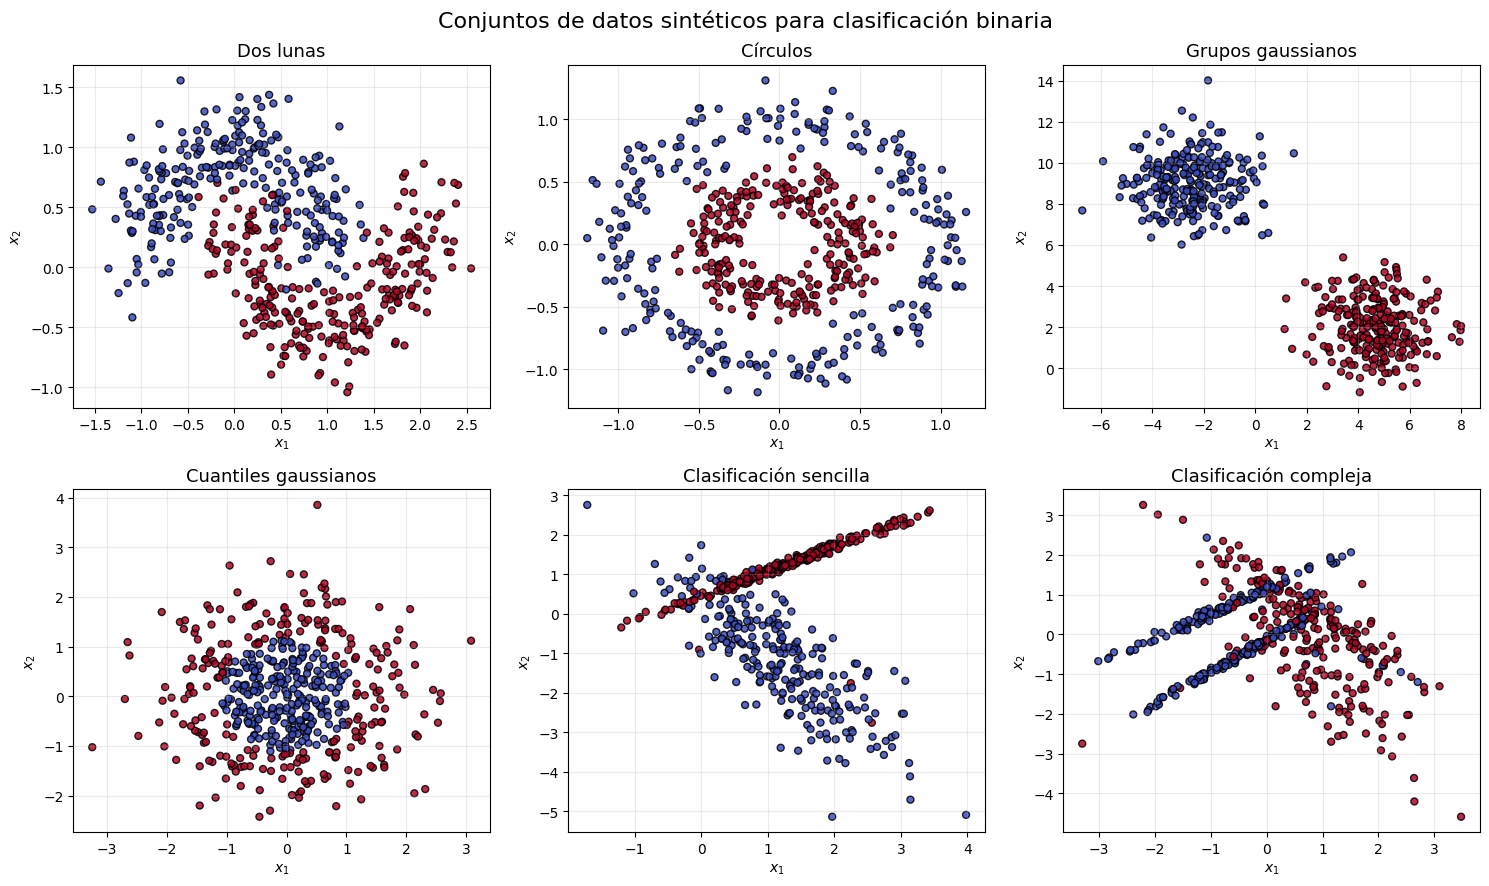

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import (
    make_moons,
    make_circles,
    make_blobs,
    make_classification,
    make_gaussian_quantiles
)

SEED = 42
N_SAMPLES = 500

# 1. Dos lunas
X_moons, y_moons = make_moons(
    n_samples=N_SAMPLES,
    noise=0.22,
    random_state=SEED
)

# 2. Círculos concéntricos
X_circles, y_circles = make_circles(
    n_samples=N_SAMPLES,
    noise=0.10,
    factor=0.45,
    random_state=SEED
)

# 3. Grupos gaussianos linealmente separables
X_blobs, y_blobs = make_blobs(
    n_samples=N_SAMPLES,
    centers=2,
    cluster_std=1.3,
    random_state=SEED
)

# 4. Distribución gaussiana concéntrica
X_gaussian, y_gaussian = make_gaussian_quantiles(
    n_samples=N_SAMPLES,
    n_features=2,
    n_classes=2,
    random_state=SEED
)

# 5. Clasificación sintética relativamente sencilla
X_class_easy, y_class_easy = make_classification(
    n_samples=N_SAMPLES,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.03,
    random_state=SEED
)

# 6. Clasificación sintética más difícil
X_class_hard, y_class_hard = make_classification(
    n_samples=N_SAMPLES,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=2,
    class_sep=0.7,
    flip_y=0.10,
    random_state=SEED
)

datasets = [
    ("Dos lunas", X_moons, y_moons),
    ("Círculos", X_circles, y_circles),
    ("Grupos gaussianos", X_blobs, y_blobs),
    ("Cuantiles gaussianos", X_gaussian, y_gaussian),
    ("Clasificación sencilla", X_class_easy, y_class_easy),
    ("Clasificación compleja", X_class_hard, y_class_hard)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, X, y) in zip(axes.ravel(), datasets):

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="k",
        s=25,
        alpha=0.85
    )

    ax.set_title(name, fontsize=13)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.grid(alpha=0.25)

plt.suptitle(
    "Conjuntos de datos sintéticos para clasificación binaria",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Documentación de conjuntos de datos de Scikit-learn

Scikit-learn proporciona documentación oficial sobre los conjuntos de datos y los generadores sintéticos disponibles:

- [Generadores de conjuntos de datos](https://scikit-learn.org/stable/datasets/sample_generators.html)
- [Referencia completa de `sklearn.datasets`](https://scikit-learn.org/stable/api/sklearn.datasets.html)
- [Ejemplo visual de comparación de clasificadores](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html)

Estos recursos permiten consultar los parámetros de funciones como `make_moons`, `make_circles`, `make_blobs`, `make_classification` y `make_gaussian_quantiles`.


## Celda para elegir el conjunto de datos

Esta celda permite que cada estudiante seleccione un problema cambiando solamente `dataset_name`.

```python
from sklearn.datasets import make_moons, make_circles, make_blobs, make_classification

def make_xor_dataset(n_samples=800, noise=0.20, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-1, 1, size=(n_samples, 2))
    y = ((X[:, 0] * X[:, 1]) > 0).astype(int)
    X += rng.normal(0, noise, size=X.shape)
    return X, y


def make_checkerboard_dataset(n_samples=800, noise=0.10, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.uniform(-2, 2, size=(n_samples, 2))

    y = (
        (np.floor(X[:, 0] + 2) + np.floor(X[:, 1] + 2)) % 2
    ).astype(int)

    X += rng.normal(0, noise, size=X.shape)
    return X, y


def select_dataset(dataset_name, n_samples=800, seed=42):

    if dataset_name == "moons":
        return make_moons(
            n_samples=n_samples,
            noise=0.25,
            random_state=seed
        )

    elif dataset_name == "circles":
        return make_circles(
            n_samples=n_samples,
            noise=0.12,
            factor=0.45,
            random_state=seed
        )

    elif dataset_name == "spirals":
        return make_spiral_dataset(
            points_per_class=n_samples // 2,
            noise=0.20,
            seed=seed
        )

    elif dataset_name == "xor":
        return make_xor_dataset(
            n_samples=n_samples,
            noise=0.15,
            seed=seed
        )

    elif dataset_name == "checkerboard":
        return make_checkerboard_dataset(
            n_samples=n_samples,
            noise=0.08,
            seed=seed
        )

    elif dataset_name == "blobs":
        X, y = make_blobs(
            n_samples=n_samples,
            centers=4,
            cluster_std=0.75,
            random_state=seed
        )

        # Convertir cuatro grupos en dos clases
        y = (y % 2).astype(int)
        return X, y

    elif dataset_name == "classification":
        return make_classification(
            n_samples=n_samples,
            n_features=2,
            n_redundant=0,
            n_informative=2,
            n_clusters_per_class=2,
            class_sep=0.8,
            flip_y=0.08,
            random_state=seed
        )

    else:
        raise ValueError("El conjunto de datos seleccionado no existe.")